Notebook 3 - Maximum Drawdown

Maximum Drawdown is the largest percentage drop from the highest portfolio value to the lowest value before a new high is reached

formula: 
- track the running peak (highest value seen so far)
- drawdown at each point = (current value - peak) / peak
- max drawdown needs a 100% just to recover

this is the metric risk managers most care about

a -50% drawdown needs a 100% gain just to recover

In [2]:
# Block 1 - rebuild data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

tickers = ['AAPL', 'MSFT', 'AMZN', 'JPM', 'XOM']
weights = np.array([0.2, 0.2, 0.2, 0.2, 0.2])

prices = yf.download(tickers, start='2023-01-01', end='2026-01-01', auto_adjust=True)['Close']
daily_returns = prices.pct_change().dropna()
portfolio_returns = daily_returns.dot(weights)

# portfolio cumulative value - starts at 1$ 
portfolio_cumulative = (1 + portfolio_returns).cumprod()

print("Data ready")
print(f"Portfolio final value: ${portfolio_cumulative.iloc[-1]:.2f} per $1 invested")

[*********************100%***********************]  5 of 5 completed

Data ready
Portfolio final value: $2.20 per $1 invested


Drawdown calculation:

- running peak = highest cumulative value seen up to each date
- drawdown = (cumulative value - running peak) / running peak
- when portfolio is at all time high -> drawdown = 0
- when portfolio drops below peak -> drawdown is negative

Maximum Drawdown: -20.2%
Occured on: 2025-04-08


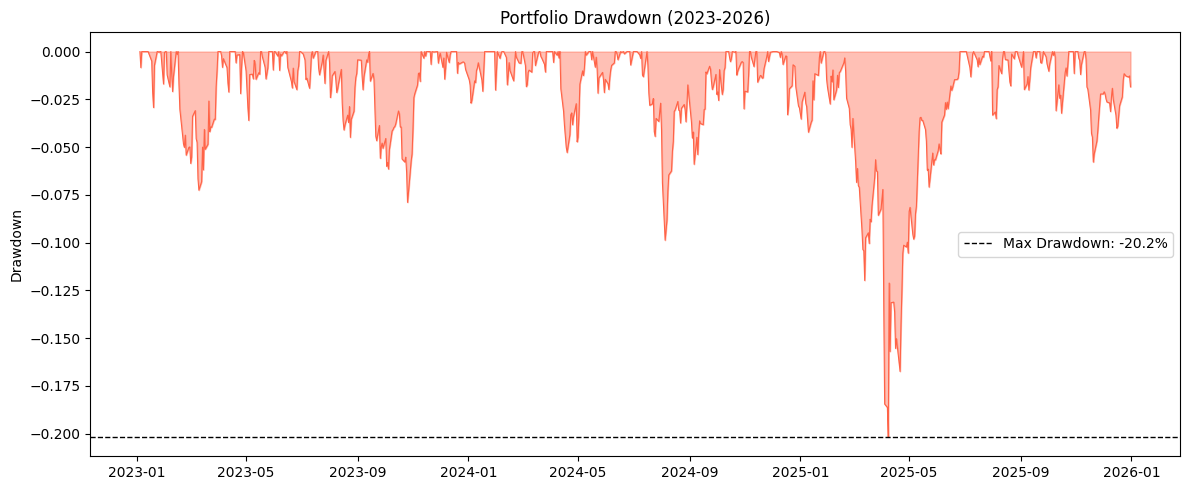

In [20]:
running_peak = portfolio_cumulative.cummax()        # cummax() tracks the maximum value up to each date

# Drawdown at each point
# negative number - how far below the peak we are
# subtracting gives the loss from the peak, and dividing by the peak expresses that loss as a percentage
drawdown = (portfolio_cumulative - running_peak) / running_peak

max_drawdown = drawdown.min()

print(f"Maximum Drawdown: {max_drawdown: .1%}")
print(f"Occured on: {drawdown.idxmin().date()}")

# plot drawdown over time
plt.figure(figsize=(12,5))
plt.fill_between(drawdown.index, drawdown, 0, color = 'tomato', alpha = 0.4)
plt.plot(drawdown, color = 'tomato', linewidth = 0.8)
plt.axhline(y=max_drawdown, color='black', linewidth=1,
            linestyle='--', label=f'Max Drawdown: {max_drawdown:.1%}')
plt.title('Portfolio Drawdown (2023-2026)')
plt.ylabel('Drawdown')
plt.legend()
plt.tight_layout()
plt.savefig('../data/drawdown.png', dpi=150)
plt.show()

Max Drawdown per stock:
 AAPL: -33.4%
 MSFT: -23.7%
 AMZN: -30.9%
 JPM: -24.4%
 XOM: -18.9%


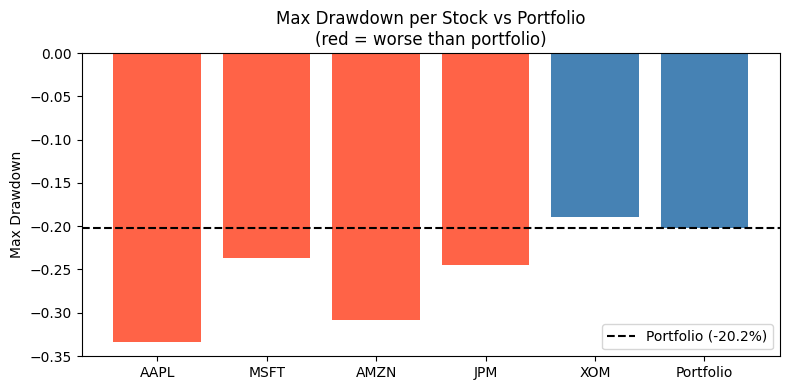

In [ ]:
# Block 3: Drawdown per stock

# compare max drawdown across all stocks vs portfolio
print("Max Drawdown per stock:")
max_drawdowns = {}

for ticker in tickers:
    cumulative = (1 + daily_returns[ticker]).cumprod()
    peak = cumulative.cummax()
    dd = (cumulative - peak) / peak     # drawdown
    max_drawdowns[ticker] = dd.min()
    print(f" {ticker}: {dd.min(): .1%}")

max_drawdowns['Portfolio'] = max_drawdown

# plot comparison
plt.figure(figsize=(8, 4))
colors = ['tomato' if v < max_drawdown else 'steelblue'
          for v in max_drawdowns.values()]

plt.bar(max_drawdowns.keys(), max_drawdowns.values(), color = colors)

plt.axhline(y=max_drawdown, color='black', linewidth=1.5,
            linestyle='--', label=f'Portfolio ({max_drawdown:.1%})')
plt.title('Max Drawdown per Stock vs Portfolio\n(red = worse than portfolio)')
plt.ylabel('Max Drawdown')
plt.legend()
plt.tight_layout()
plt.savefig('../data/max_drawdown.png', dpi=150)
plt.show()

Portfolio: -20.2%, worst point April 8, 2025

diversification reduced maximum drawdown by ~13 percentage points versus the worst individual holding.